In [2]:
import pandas as pd  # base tabular
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # opcional — gráficos interativos se quiser brincar depois
import plotly.graph_objects as go



In [3]:
# Mesmo CSV do portal (nome DiariasEPassagens_... no relatório genérico; pode ser cópia renomeada desde que o schema seja o mesmo)
df = pd.read_csv(
    'DiariasEPassagens_ultimos_2_anos.csv',
    low_memory=False,
    encoding='utf-8',
)
df = df.drop_duplicates()  # alinha com o relatório principal — daily_rates ou rene_estevam_deckers (duplicatas aparecem nos dados abertos)



In [4]:
# Mesma lógica dos relatórios: valores monetários e diárias vêm como texto com vírgula
def acha_col(df, *nomes):
    for n in nomes:
        if n in df.columns:
            return n
    for c in df.columns:
        if any(n in c for n in nomes) or c.replace('\u00ad', '').strip() in nomes:
            return c
    return None


def acha_por_palavras(df, palavras):
    for c in df.columns:
        if all(p.lower() in c.lower() for p in palavras):
            return c
    return None


col_valor_total = acha_col(df, 'Valor total') or acha_por_palavras(df, ['Valor', 'total'])
col_valor_diarias = acha_col(df, 'Valor diárias', 'Valor diarias') or acha_por_palavras(df, ['Valor', 'diarias'])
col_valor_passagem = acha_col(df, 'Valor passagem') or acha_por_palavras(df, ['Valor', 'passagem'])
col_num_diarias = (
    acha_col(df, 'Número diárias', 'Numero diarias')
    or acha_por_palavras(df, ['Número', 'diárias'])
    or acha_por_palavras(df, ['Numero', 'diarias'])
)


def to_num(s):
    if pd.isna(s):
        return np.nan
    return pd.to_numeric(str(s).strip().replace(',', '.'), errors='coerce')


for col in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias]:
    if col is not None and col in df.columns:
        df[col] = df[col].apply(to_num)

df['valor_total_num'] = df[col_valor_total]
cols_num = [c for c in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias] if c and c in df.columns]
print('Shape:', df.shape)
print('Colunas numéricas convertidas:', cols_num)
df[cols_num].describe()



Shape: (2215246, 24)
Colunas numéricas convertidas: ['Valor total', 'Valor diárias', 'Valor passagem', 'Número diárias']


,Valor total,Valor diárias,Valor passagem,Número diárias
count,2.215234e+06,2.215234e+06,2.215234e+06,2.215246e+06
mean,1.496572e+03,3.715609e+02,1.741149e+02,1.684505e+00
std,4.202900e+03,1.282214e+03,5.114744e+02,6.893082e+00
min,-3.071400e+02,0.000000e+00,-2.346000e+01,0.000000e+00
25%,2.238600e+02,8.850000e+01,0.000000e+00,5.000000e-01
50%,6.924000e+02,1.062000e+02,0.000000e+00,5.000000e-01
75%,1.659060e+03,3.100000e+02,0.000000e+00,1.000000e+00
max,1.631613e+05,1.517607e+05,3.340776e+04,4.481760e+03


In [5]:
df.head()  # sanity check: cabeçalho bate com o que esperávamos?



,Código órgão superior,Nome órgão superior,Código órgão,Nome órgão,Código unidade gestora,Nome unidade gestora,Nome servidor,Cargo,Data início viagem,Data término viagem,...,Município origem,UF origem,Município destino,UF destino,Número diárias,Valor diárias,Meio de transporte,Categoria passagem,Valor passagem,valor_total_num
0,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,2.0,642.56,Veículo Oficial,NaN,0.0,803.20
1,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,0.5,160.64,Veículo Oficial,NaN,0.0,803.20
2,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-06-30,2017-07-02 00:00:00,...,NaN,NaN,NaN,NaN,1.0,386.36,Veículo Oficial,NaN,0.0,579.54
3,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-06-30,2017-07-02 00:00:00,...,NaN,NaN,NaN,NaN,0.5,193.18,Veículo Oficial,NaN,0.0,579.54
4,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-08-14,2017-08-15 00:00:00,...,NaN,NaN,NaN,NaN,0.5,182.00,Veículo Oficial,NaN,0.0,364.00


In [6]:
df.info()  # tipos após conversão (valores já float onde aplicável)
df.describe(include='all')  # inclui object — útil pra ver cardinalidade grosseira
df.isnull().sum()
print('Duplicatas (após remoção na carga):', df.duplicated().sum())
df.shape



<class 'pandas.DataFrame'>
Index: 2215246 entries, 0 to 2241587
Data columns (total 24 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Código órgão superior   int64  
 1   Nome órgão superior     str    
 2   Código órgão            int64  
 3   Nome órgão              str    
 4   Código unidade gestora  float64
 5   Nome unidade gestora    str    
 6   Nome servidor           str    
 7   Cargo                   str    
 8   Data início viagem      str    
 9   Data término viagem     str    
 10  Motivo                  str    
 11  Valor total             float64
 12  Início trecho           str    
 13  Término trecho          str    
 14  Município origem        str    
 15  UF origem               str    
 16  Município destino       str    
 17  UF destino              str    
 18  Número diárias          float64
 19  Valor diárias           float64
 20  Meio de transporte      str    
 21  Categoria passagem      str    
 22  Valor pass

(2215246, 24)

### Exploração rápida

- **Série mensal:** soma de `valor_total_num` por mês de **Data início viagem** (útil para sazonalidade e tendência).
- **Top 10 órgãos:** `Nome órgão superior` com maior soma de valor (milhões de R$).
- **Consistência:** quantos registros divergem de `Valor diárias + Valor passagem` em relação a `Valor total` (tolerância de R$ 0,02 — arredondamentos/lançamentos podem explicar pequenas diferenças).


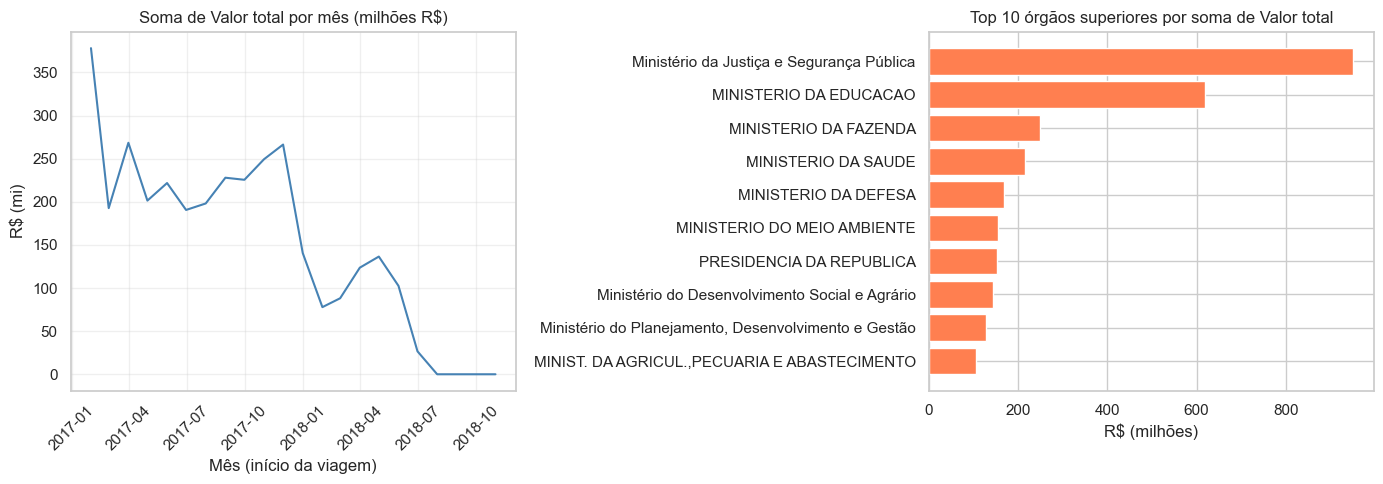

                                 Nome órgão superior  registros  valor_total
           Ministério da Justiça e Segurança Pública     298430 950545064.11
                              MINISTERIO DA EDUCACAO     588958 618295650.32
                               MINISTERIO DA FAZENDA     197644 248778056.13
                                 MINISTERIO DA SAUDE     121757 215768024.14
                                MINISTERIO DA DEFESA     127935 168473988.27
                         MINISTERIO DO MEIO AMBIENTE      79996 155676758.45
                            PRESIDENCIA DA REPUBLICA     127795 152001668.01
      Ministério do Desenvolvimento Social e Agrário     139366 143311109.14
Ministério do Planejamento, Desenvolvimento e Gestão     152131 127280512.95
        MINIST. DA AGRICUL.,PECUARIA E ABASTECIMENTO     108509 104610796.92

Registros com |Valor total − (diárias + passagem)| > 0.02: 2141190 (96.66%)


In [7]:
sns.set_theme(style='whitegrid')

# Achar coluna de data mesmo se o nome vier com grafia levemente diferente
col_data = next(
    (c for c in df.columns if 'início' in c.lower() and 'viagem' in c.lower()),
    'Data início viagem',
)
df['_dt_inicio'] = pd.to_datetime(df[col_data], errors='coerce')
mensal = (
    df.dropna(subset=['_dt_inicio'])
    .groupby(pd.Grouper(key='_dt_inicio', freq='ME'))['valor_total_num']
    .sum()
    .reset_index()
)

col_org = 'Nome órgão superior'
top_org = (
    df.groupby(col_org, as_index=False)
    .agg(registros=('valor_total_num', 'size'), valor_total=('valor_total_num', 'sum'))
    .sort_values('valor_total', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mensal['_dt_inicio'], mensal['valor_total_num'] / 1e6, color='steelblue')  # eixo em milhões pra não encher de zeros
axes[0].set_title('Soma de Valor total por mês (milhões R$)')
axes[0].set_xlabel('Mês (início da viagem)')
axes[0].set_ylabel('R$ (mi)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_org[col_org][::-1], top_org['valor_total'][::-1] / 1e6, color='coral')  # [::-1] deixa o maior em cima
axes[1].set_title('Top 10 órgãos superiores por soma de Valor total')
axes[1].set_xlabel('R$ (milhões)')
plt.tight_layout()
plt.show()

print(top_org.to_string(index=False))

# Checagem rápida: na teoria total ≈ diárias + passagem (centavos podem fugir um pouco)
soma_partes = df[col_valor_diarias].fillna(0) + df[col_valor_passagem].fillna(0)
diff = (df['valor_total_num'] - soma_partes).abs()
tol = 0.02  # 2 centavos — margem pra arredondamento / lançamentos estranhos
n_div = int((diff > tol).sum())
print(f'\nRegistros com |Valor total − (diárias + passagem)| > {tol}: {n_div} ({100 * n_div / len(df):.2f}%)')

df.drop(columns=['_dt_inicio'], inplace=True, errors='ignore')  # coluna auxiliar — não poluir o df da sessão

